In [107]:
# Import packages
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [108]:
# Import data
df = pd.read_csv(Path('data/processed') / 'panel_data.csv')

In [ ]:
# Take a look at dataframe
df.head()

,country,year,log_gdppc_growth,rgdpe,rgdp_pc,tariff,tariff_sd,tariff_lag1,tariff_lag2,trade_gdp,income_group
0,Albania,1997,-20.280174,12118.621094,3752.290053,19.35,7.81,NaN,NaN,44.7293780649181,Low-income countries
1,Albania,1997,-20.280174,12118.621094,3752.290053,13.59,5.96,19.35,NaN,44.7293780649181,Low-income countries
2,Albania,1997,-20.280174,12118.621094,3752.290053,7.79,5.50,13.59,19.35,44.7293780649181,Low-income countries
3,Albania,1997,-20.280174,12118.621094,3752.290053,12.37,5.48,7.79,13.59,44.7293780649181,Low-income countries
4,Albania,2000,10.814410,14723.368164,4650.246345,10.36,5.82,12.37,7.79,61.6092610436407,Lower-middle-income countries


In [110]:
def line_plot(df, variable):
    '''Plot the average of a variable by year over the time period.'''
    
    # Ensure variable is numeric
    df[variable] = pd.to_numeric(df[variable], errors='coerce')
    
    # Group by year and compute average
    year_avg = df.groupby('year')[variable].mean()

    # Create line plot
    plt.figure(figsize=(6, 3))
    plt.plot(year_avg.index, year_avg.values)
    plt.xlabel('Year')
    plt.ylabel(f'Average {variable}')
    plt.title(f'Average {variable} over time')
    plt.show()

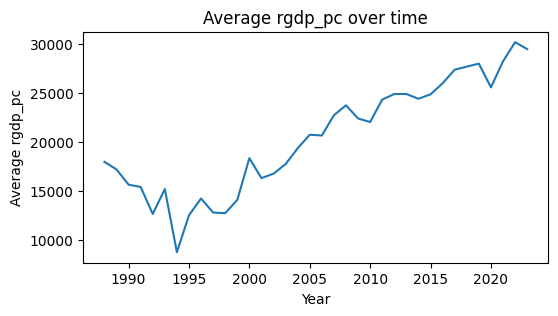

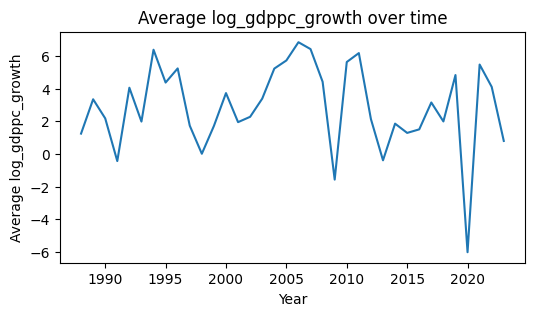

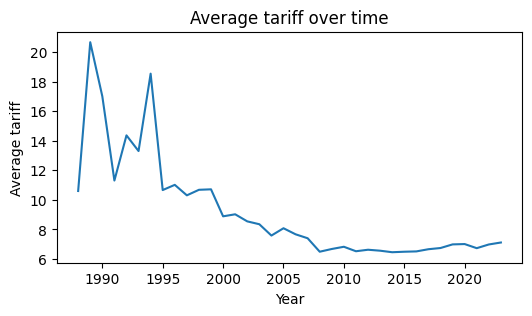

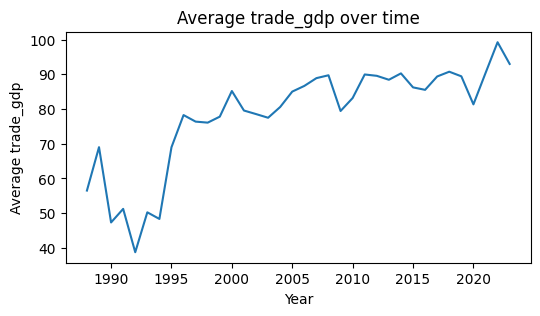

In [111]:
# Make plots of variables
line_plot(df, 'rgdp_pc')
line_plot(df, 'log_gdppc_growth')
line_plot(df, 'tariff')
line_plot(df, 'trade_gdp')

In [112]:
def scatter_plot(df, x_var, y_var, x_cap_quantile = 1, y_cap_quantile = 1):
    '''Create a scatter plot of two variables.'''
    
    # Ensure variable is numeric 
    df[x_var] = pd.to_numeric(df[x_var], errors='coerce')
    df[y_var] = pd.to_numeric(df[y_var], errors='coerce')


    # Optionally cap axes at a high quantile to reduce impact of extreme outliers
    if x_cap_quantile is not None:
        x_cap = df[x_var].quantile(x_cap_quantile)
        df = df[df[x_var] <= x_cap]

    if y_cap_quantile is not None:
        y_cap = df[y_var].quantile(y_cap_quantile)
        df = df[df[y_var] <= y_cap]

    # Create scatter plot
    plt.figure(figsize=(6, 3))
    plt.scatter(df[x_var], df[y_var])
    plt.xlabel(x_var)
    plt.ylabel(y_var)
    plt.title(f'{y_var} vs {x_var}')
    plt.show()

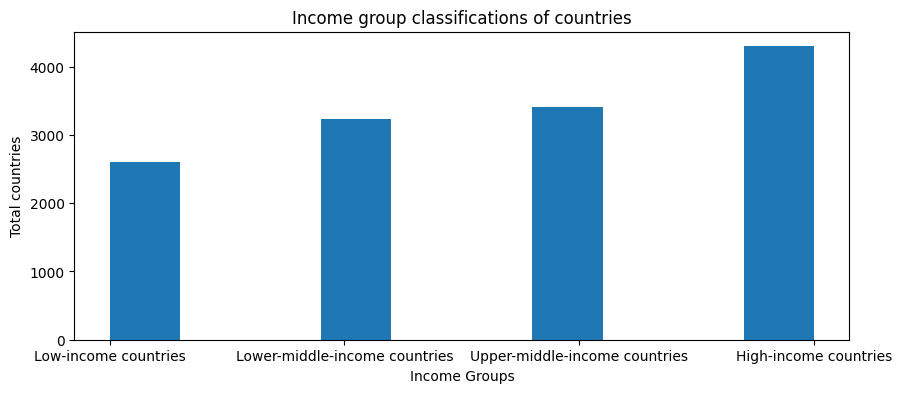

In [142]:
# Create histogram with income group distribution
plt.figure(figsize=(10, 4))
plt.hist(df['income_group'])
plt.xlabel('Income Groups')
plt.ylabel('Total countries')
plt.title('Income group classifications of countries')
plt.show()

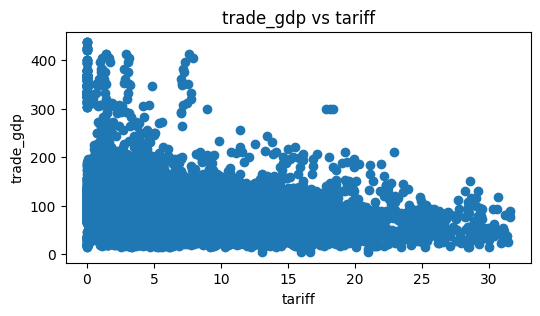

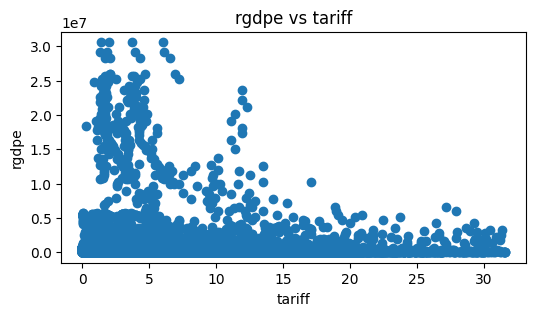

In [113]:
# Create scatter plot with tariffs and trade as % of GDP
scatter_plot(df, 'tariff', 'trade_gdp', 0.99)

# Create scatter plot with real tariffs and trade as % of GDP
scatter_plot(df, 'tariff', 'rgdpe', 0.99)